In [ ]:
import pickle
import pandas as pd
from textblob import TextBlob
import nltk
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
import sys
import tweepy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import nltk
import pycountry
import re
import string
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
from langdetect import detect
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Ładowanie Tweetów z pliku pikle dotyczących Trumpa, Bidena oraz wyborów

In [ ]:
tweets_texts = []
list_tw = ['Trump', 'Biden', 'Election']
# Otworzenie pliku
for i in list_tw:
    with open(f"{i}_tweets.pkl", "rb") as file:
        # Nieskonczona petla przechodzaca po tweetach
        while True:
            try:
                # Załadowanie do zmiennej tweeta z jego metdanymi
                tweet = pickle.load(file)
                # Zapisanie treści tweetów do pustej listy tweets_texts
                tweets_texts.append((tweet['full_text'],
                                     tweet['created_at'],
                                     tweet['entities']['hashtags'],
                                     tweet['metadata']['iso_language_code'],
                                     tweet['retweet_count'],
                                     tweet['favorite_count'],
#                                      tweet['user']['entities']['followers_count'],
#                                      tweet['user']['entities']['friends_count'],
#                                      tweet['user']['entities']['created_count'],
                                     i))
            except EOFError:
                # Koniec pliku, wyjdz z petli
                break
df = pd.DataFrame(tweets_texts)

In [ ]:
#zmiana nazwy kolumn
df.rename(columns={0: 'Tweet', 1: 'data_tweetu', 2:'hashtags',
                   3: 'jezyk', 4: 'liczba_retweetow', 5: 'liczba_polubien',
                   6: 'Plik'}, inplace=True)

In [ ]:
#usuwanie duplikatow
df['Tweet'].drop_duplicates(inplace = True)

In [ ]:
#czyszczenie tekstu
tw_list = pd.DataFrame(df)
tw_list["Text"] = tw_list['Tweet']

#Removing RT, Punctuation etc
remove_rt = lambda x: re.sub('RT @\w+: ', " ", x)
rt = lambda x: re.sub("(@[A-Za-z0–9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)"," ",x)
tw_list["Text"] = tw_list.Text.map(remove_rt).map(rt)
tw_list["Text"] = tw_list.Text.str.lower()
tw_list.head(10)

In [ ]:
#Liczenie pozytwnego, negatwnego oraz łączonego sentymentu
tw_list[['polarity', 'subjectivity']] = tw_list['Text'].apply(lambda Text: pd.Series(TextBlob(Text).sentiment))
for index, row in tw_list['Text'].iteritems():
    score = SentimentIntensityAnalyzer().polarity_scores(row)
    neg = score['neg']
    neu = score['neu']
    pos = score['pos']
    comp = score['compound']
    if neg > pos:
        tw_list.loc[index, 'sentiment'] = "negative"
    elif pos > neg:
        tw_list.loc[index, 'sentiment'] = "positive"
    else:
        tw_list.loc[index, 'sentiment'] = "neutral"
    tw_list.loc[index, 'neg'] = neg
    tw_list.loc[index, 'neu'] = neu
    tw_list.loc[index, 'pos'] = pos
    tw_list.loc[index, 'compound'] = comp
tw_list.head(1)

In [ ]:
df.head()

,Tweet,data_tweetu,hashtags,jezyk,liczba_retweetow,liczba_polubien,Plik,Text,polarity,subjectivity,sentiment,neg,neu,pos,compound
0,"RT @ThomboyD: Ok, how many warnings does trump...",Thu Oct 22 23:59:59 +0000 2020,[],en,1,0,Trump,ok how many warnings does trump get before h...,0.34,0.393333,negative,0.165,0.755,0.079,-0.3400
1,RT @JonahDispatch: Lara Trump has said three t...,Thu Oct 22 23:59:59 +0000 2020,[],en,1830,0,Trump,lara trump has said three times during an int...,0.00,0.000000,neutral,0.000,1.000,0.000,0.0000
2,RT @jburnmurdoch: I particularly love this won...,Thu Oct 22 23:59:59 +0000 2020,[],en,39,0,Trump,i particularly love this wonderful graphic fr...,0.60,0.750000,positive,0.057,0.390,0.553,0.9432
3,RT @AliVelshi: BREAKING: A federal judge in NJ...,Thu Oct 22 23:59:59 +0000 2020,[],en,1959,0,Trump,breaking a federal judge in nj has dismissed...,0.50,1.000000,negative,0.097,0.821,0.082,-0.0772
4,RT @RepsForBiden: Let’s make sure Trump is bei...,Thu Oct 22 23:59:59 +0000 2020,"[{'text': 'BejingDon', 'indices': [123, 133]}]",en,1469,0,Trump,let s make sure trump is being asked about hi...,0.05,0.794444,positive,0.000,0.897,0.103,0.3182


In [ ]:
tw_list.head()

,Tweet,data_tweetu,hashtags,jezyk,liczba_retweetow,liczba_polubien,Plik,Text,polarity,subjectivity,sentiment,neg,neu,pos,compound
0,"RT @ThomboyD: Ok, how many warnings does trump...",Thu Oct 22 23:59:59 +0000 2020,[],en,1,0,Trump,ok how many warnings does trump get before h...,0.34,0.393333,negative,0.165,0.755,0.079,-0.3400
1,RT @JonahDispatch: Lara Trump has said three t...,Thu Oct 22 23:59:59 +0000 2020,[],en,1830,0,Trump,lara trump has said three times during an int...,0.00,0.000000,neutral,0.000,1.000,0.000,0.0000
2,RT @jburnmurdoch: I particularly love this won...,Thu Oct 22 23:59:59 +0000 2020,[],en,39,0,Trump,i particularly love this wonderful graphic fr...,0.60,0.750000,positive,0.057,0.390,0.553,0.9432
3,RT @AliVelshi: BREAKING: A federal judge in NJ...,Thu Oct 22 23:59:59 +0000 2020,[],en,1959,0,Trump,breaking a federal judge in nj has dismissed...,0.50,1.000000,negative,0.097,0.821,0.082,-0.0772
4,RT @RepsForBiden: Let’s make sure Trump is bei...,Thu Oct 22 23:59:59 +0000 2020,"[{'text': 'BejingDon', 'indices': [123, 133]}]",en,1469,0,Trump,let s make sure trump is being asked about hi...,0.05,0.794444,positive,0.000,0.897,0.103,0.3182


In [ ]:
tw_list.to_csv('ProjektTextMining.csv')

In [ ]:
tw_list_negative = tw_list[tw_list["sentiment"]=="negative"]
tw_list_positive = tw_list[tw_list["sentiment"]=="positive"]
tw_list_neutral = tw_list[tw_list["sentiment"]=="neutral"]

In [ ]:
def count_values_in_column(data,feature):
    total=data.loc[:,feature].value_counts(dropna=False)
    percentage=round(data.loc[:,feature].value_counts(dropna=False,normalize=True)*100,2)
    return pd.concat([total,percentage],axis=1,keys=['Total','Percentage'])
#Count_values for sentiment
pc = count_values_in_column(tw_list,"sentiment")

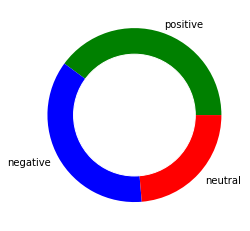

In [ ]:
# create data for Pie Chart
pichart = count_values_in_column(tw_list,"sentiment")
names= pc.index
size=pc["Percentage"]

# Create a circle for the center of the plot
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(size, labels=names, colors=['green','blue','red'])
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [ ]:
def create_wordcloud(text):
    #mask = np.array(Image.open("cloud.png"))
    stopwords = set(STOPWORDS)
    wc = WordCloud(background_color="white",
    #mask = mask,
    max_words=3000,
    stopwords=stopwords,
    repeat=True)
    wc.generate(str(text))
    #wc.to_file("wc.png")
#     print("Word Cloud Saved Successfully")
#     path="wc.png"
#     display(Image.open(path))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()

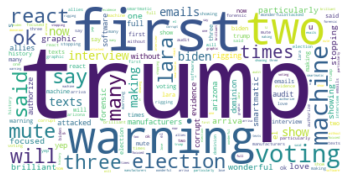

In [ ]:
#Creating wordcloud for all tweets
create_wordcloud(tw_list["Text"].values)

In [ ]:
import pandas as pd

df = pd.read_csv('ProjektTextMining.csv')
df.head()

,Unnamed: 0,Tweet,data_tweetu,hashtags,jezyk,liczba_retweetow,liczba_polubien,Plik,Text,polarity,subjectivity,sentiment,neg,neu,pos,compound
0,0,"RT @ThomboyD: Ok, how many warnings does trump...",Thu Oct 22 23:59:59 +0000 2020,[],en,1,0,Trump,ok how many warnings does trump get before h...,0.340000,0.393333,negative,0.165,0.755,0.079,-0.3400
1,1,RT @JonahDispatch: Lara Trump has said three t...,Thu Oct 22 23:59:59 +0000 2020,[],en,1830,0,Trump,lara trump has said three times during an int...,0.000000,0.000000,neutral,0.000,1.000,0.000,0.0000
2,2,RT @jburnmurdoch: I particularly love this won...,Thu Oct 22 23:59:59 +0000 2020,[],en,39,0,Trump,i particularly love this wonderful graphic fr...,0.600000,0.750000,positive,0.057,0.390,0.553,0.9432
3,3,RT @AliVelshi: BREAKING: A federal judge in NJ...,Thu Oct 22 23:59:59 +0000 2020,[],en,1959,0,Trump,breaking a federal judge in nj has dismissed...,0.500000,1.000000,negative,0.097,0.821,0.082,-0.0772
4,4,RT @RepsForBiden: Let’s make sure Trump is bei...,Thu Oct 22 23:59:59 +0000 2020,"[{'text': 'BejingDon', 'indices': [123, 133]}]",en,1469,0,Trump,let s make sure trump is being asked about hi...,0.050000,0.794444,positive,0.000,0.897,0.103,0.3182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,RT @Cernovich: Tonight’s debate moderator melt...,Thu Oct 22 23:59:39 +0000 2020,[],en,976,0,Trump,tonight s debate moderator melted down when i...,-0.155556,0.288889,negative,0.260,0.620,0.120,-0.5267
996,996,RT @mattmfm: It’s outrageous that the every ar...,Thu Oct 22 23:59:39 +0000 2020,[],en,1828,0,Trump,it s outrageous that the every article doesn ...,-1.000000,1.000000,negative,0.143,0.857,0.000,-0.4588
997,997,1/ This perfectly captures the Trump-like appr...,Thu Oct 22 23:59:39 +0000 2020,[],en,6,12,Trump,1 this perfectly captures the trump like appr...,0.333333,0.833333,positive,0.046,0.671,0.283,0.8839
998,998,RT @Justaranch: Remember the “repeal and repla...,Thu Oct 22 23:59:39 +0000 2020,[],en,25,0,Trump,remember the repeal and replace chant for ...,0.000000,0.000000,negative,0.136,0.864,0.000,-0.5106


In [ ]:
#zamienienie str na datetime
df['data_tweetu'] = pd.to_datetime(df['data_tweetu'], format='%a %b %d %H:%M:%S %z %Y')

In [ ]:
#dodanie dnia napisania tweetu
df['dzien_tweetu'] = df['data_tweetu'].apply(lambda data_tweetu: data_tweetu.date())

In [ ]:
#pogrupowanie po sentymencie i dacie
df2 = df.groupby(['dzien_tweetu', 'sentiment', 'Plik']).size().reset_index(name='Liczba tweetów')
df2.head()

,dzien_tweetu,sentiment,Plik,Liczba tweetów
0,2020-10-22,negative,Biden,4207
1,2020-10-22,negative,Trump,8381
2,2020-10-22,neutral,Biden,5073
3,2020-10-22,neutral,Trump,5249
4,2020-10-22,positive,Biden,4054


In [ ]:
#podzielenie na pliki dla poszczegolnych kategorii
df_biden = df[df['Plik'] == 'Biden']
df_election = df[df['Plik'] == 'Election']
df_trump = df[df['Plik'] == 'Trump']

In [ ]:
#zgrupowane dla każdej z kategorii
df_gr = df.groupby(['dzien_tweetu', 'sentiment']).size().reset_index(name='Liczba tweetów')
df_biden_gr = df_biden.groupby(['dzien_tweetu', 'sentiment']).size().reset_index(name='Liczba tweetów')
df_election_gr = df_election.groupby(['dzien_tweetu', 'sentiment']).size().reset_index(name='Liczba tweetów')
df_trump_gr = df_trump.groupby(['dzien_tweetu', 'sentiment']).size().reset_index(name='Liczba tweetów')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

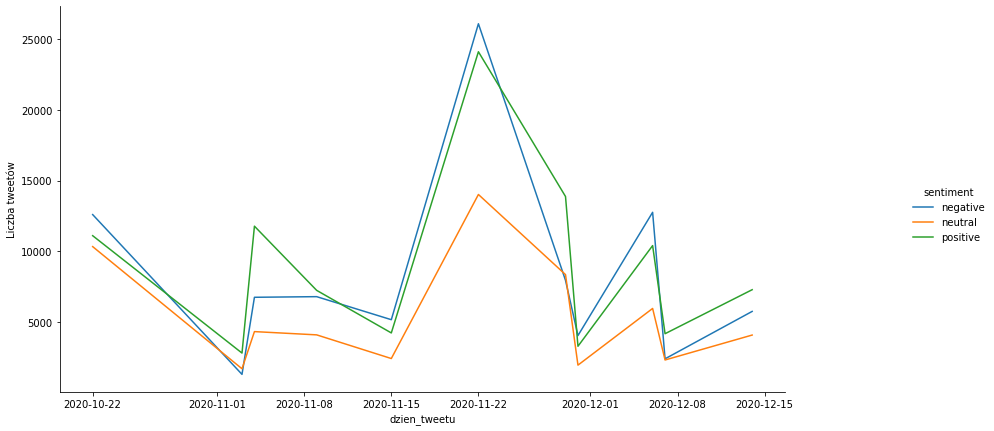

In [ ]:
#wizualizacja przedstawiająca liczbę tweetów w poszczególnych językach na przestrzeni czasu łącznie
sns.relplot(data=df_gr, x="dzien_tweetu", y="Liczba tweetów", hue="sentiment", kind="line")
plt.gcf().set_size_inches(15, 6)

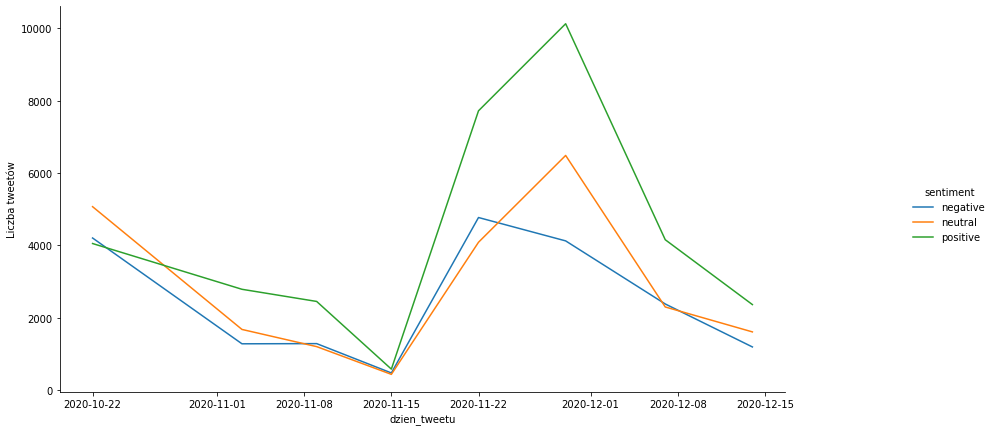

In [ ]:
#wizualizacja przedstawiająca liczbę tweetów w poszczególnych językach na przestrzeni czasu dla bidena
sns.relplot(data=df_biden_gr, x="dzien_tweetu", y="Liczba tweetów", hue="sentiment", kind="line")
plt.gcf().set_size_inches(15, 6)

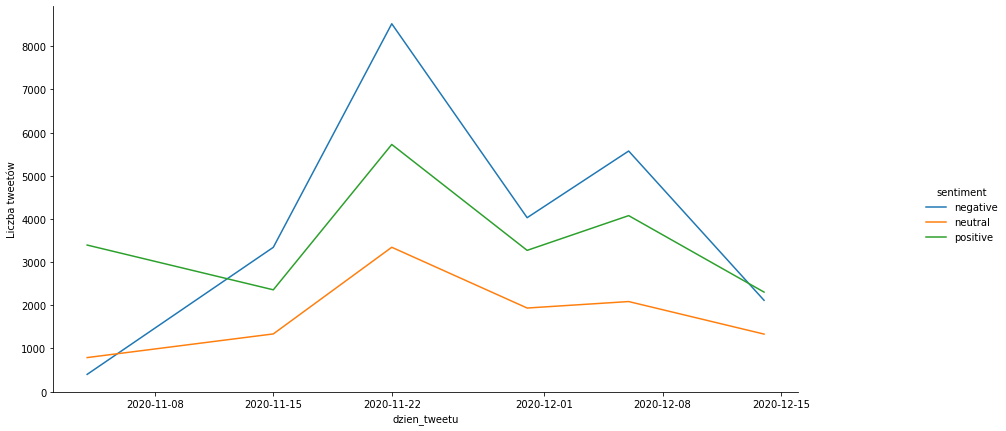

In [ ]:
#wizualizacja przedstawiająca liczbę tweetów w poszczególnych językach na przestrzeni czasu dla election
sns.relplot(data=df_election_gr, x="dzien_tweetu", y="Liczba tweetów", hue="sentiment", kind="line")
plt.gcf().set_size_inches(15, 6)

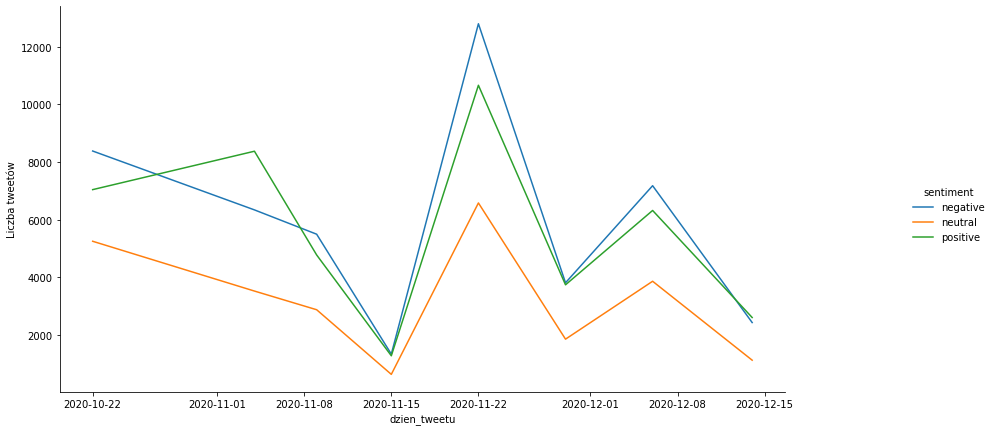

In [ ]:
#wizualizacja przedstawiająca liczbę tweetów w poszczególnych językach na przestrzeni czasu dla trumpa
sns.relplot(data=df_trump_gr, x="dzien_tweetu", y="Liczba tweetów", hue="sentiment", kind="line")
plt.gcf().set_size_inches(15, 6)

In [ ]:
df[df['dzien_tweetu'] == '2020-10-22']

,Unnamed: 0,Tweet,data_tweetu,hashtags,jezyk,liczba_retweetow,liczba_polubien,Plik,Text,polarity,subjectivity,sentiment,neg,neu,pos,compound,dzien_tweetu


In [ ]:
df

,Unnamed: 0,Tweet,data_tweetu,hashtags,jezyk,liczba_retweetow,liczba_polubien,Plik,Text,polarity,subjectivity,sentiment,neg,neu,pos,compound,dzien_tweetu
0,0,"RT @ThomboyD: Ok, how many warnings does trump...",2020-10-22 23:59:59+00:00,[],en,1,0,Trump,ok how many warnings does trump get before h...,0.34,0.393333,negative,0.165,0.755,0.079,-0.3400,2020-10-22
1,1,RT @JonahDispatch: Lara Trump has said three t...,2020-10-22 23:59:59+00:00,[],en,1830,0,Trump,lara trump has said three times during an int...,0.00,0.000000,neutral,0.000,1.000,0.000,0.0000,2020-10-22
2,2,RT @jburnmurdoch: I particularly love this won...,2020-10-22 23:59:59+00:00,[],en,39,0,Trump,i particularly love this wonderful graphic fr...,0.60,0.750000,positive,0.057,0.390,0.553,0.9432,2020-10-22
3,3,RT @AliVelshi: BREAKING: A federal judge in NJ...,2020-10-22 23:59:59+00:00,[],en,1959,0,Trump,breaking a federal judge in nj has dismissed...,0.50,1.000000,negative,0.097,0.821,0.082,-0.0772,2020-10-22
4,4,RT @RepsForBiden: Let’s make sure Trump is bei...,2020-10-22 23:59:59+00:00,"[{'text': 'BejingDon', 'indices': [123, 133]}]",en,1469,0,Trump,let s make sure trump is being asked about hi...,0.05,0.794444,positive,0.000,0.897,0.103,0.3182,2020-10-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251013,251013,@burgessev @carlquintanilla A stolen election ...,2020-12-14 23:53:03+00:00,[],en,0,0,Election,a stolen election will have consequences ...,0.00,0.000000,negative,0.307,0.693,0.000,-0.6497,2020-12-14
251014,251014,@Corey60561533 @ChiCyph80 @AlexSamuelsx5 @DemF...,2020-12-14 23:53:03+00:00,[],en,0,0,Election,60561533 80 5 no it didn t trump won i...,0.25,0.416667,positive,0.064,0.723,0.214,0.7351,2020-12-14
251015,251015,RT @kylegriffin1: Smartmatic—one of two voting...,2020-12-14 23:53:03+00:00,[],en,1688,0,Election,smartmatic one of two voting machine manufact...,0.00,0.000000,negative,0.143,0.857,0.000,-0.4588,2020-12-14
251016,251016,RT @Bubblebathgirl: Why did Arizona just autho...,2020-12-14 23:53:03+00:00,[],en,463,0,Election,why did arizona just authorize a full forensi...,0.35,0.550000,negative,0.109,0.891,0.000,-0.2960,2020-12-14
